<a href="https://colab.research.google.com/github/ayushbiitg/neuralNetworksLearnings/blob/main/Backpropogation_micrograd_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

About derivatives -> 𝑓′(𝑥)=limℎ→0 (𝑓(𝑥+ℎ)−𝑓(𝑥)) / ℎ

In [3]:
def f(x):
  return 3*x**2 - 4*x + 5

f(3.0)

20.0

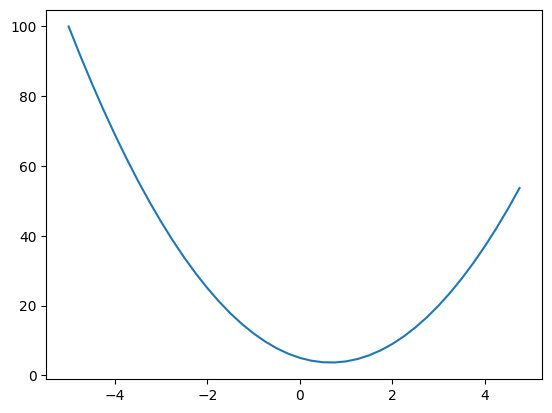

In [4]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)

plt.plot(xs, ys)

In [9]:
h = 0.001
x = 2/3
slope = (f(x+h) - f(x))/h
slope


0.0029999999995311555

In [10]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


b,c:  -3.0 10.0
xa: [-5.   -4.75 -4.5  -4.25 -4.   -3.75 -3.5  -3.25 -3.   -2.75 -2.5  -2.25
 -2.   -1.75 -1.5  -1.25 -1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75
  1.    1.25  1.5   1.75  2.    2.25  2.5   2.75  3.    3.25  3.5   3.75
  4.    4.25  4.5   4.75]
ya: [25.   24.25 23.5  22.75 22.   21.25 20.5  19.75 19.   18.25 17.5  16.75
 16.   15.25 14.5  13.75 13.   12.25 11.5  10.75 10.    9.25  8.5   7.75
  7.    6.25  5.5   4.75  4.    3.25  2.5   1.75  1.    0.25 -0.5  -1.25
 -2.   -2.75 -3.5  -4.25]


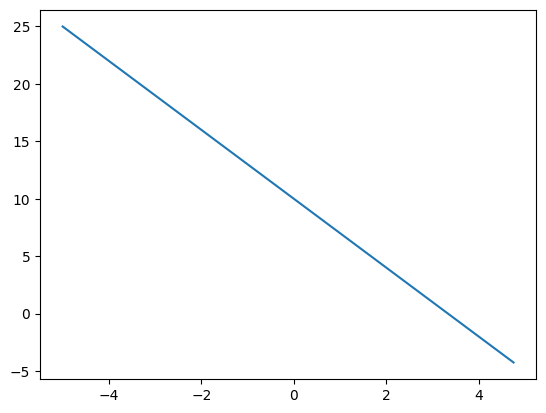

In [22]:
xa = np.arange(-5, 5, 0.25)

print('b,c: ',b,c)
print('xa:',xa)
ya = lambda x: x*b +c
print('ya:',ya(xa))
plt.plot(xa, ya(xa))
# plt.plot()

In [24]:
slope = (-4.25 - 25)/ (4.75 - (-5))
slope

-3.0

In [26]:
h = 0.0001

D = (ya(xa + h) - ya(xa))/ h

In [27]:
D

array([-3., -3., -3., -3., -3., -3., -3., -3., -3., -3., -3., -3., -3.,
       -3., -3., -3., -3., -3., -3., -3., -3., -3., -3., -3., -3., -3.,
       -3., -3., -3., -3., -3., -3., -3., -3., -3., -3., -3., -3., -3.,
       -3.])

# Backtracking

In [53]:
class Value:
  def __init__(self, data, children=(), _op="", label=""):
    self.data = data
    self._prev = set(children)
    self._op = _op
    self.label = label

  def __repr__(self) -> str:
    return f"Value(data={self.data})"

  def __add__(self, other):
    out = Value(self.data + other.data , (self, other), "+")
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data , (self, other), "*")
    return out




a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10.0, label="c")
e = a*b; e.label = "e"
d = e + c; d.label = "d"
f = Value(-2.0, label="f")
L = d*f; L.label = "L"


In [54]:
print(d._prev)
print(d._op)

{Value(data=10.0), Value(data=-6.0)}
+


In [58]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | %.4f }" % (n.label, n.data), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

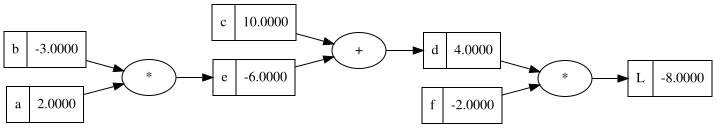

In [59]:
draw_dot(L)